# 01 · Exploración de datos Optimización de rutas GAM

Este notebook prepara la red vial de San José, integra la información distrital del INEC y
los destinos estratégicos de OSM, y hace el análisis exploratorio de datos (EDA) que
alimenta la formulación matemática del proyecto.

Se ejecuta de principio a fin sin intervención manual. Todos los datos se leen desde
`data/raw/` y `data/processed/`, ya incluidos en el repositorio.

## Ubicación en el temario del curso (BCD5105 Modelado Matemático)

Este proyecto combina explícitamente dos bloques del curso:

- **Tema 10 (Modelado mediante teoría de grafos):** la red vial se representa como un grafo
  dirigido y se resuelve con algoritmos clásicos de camino mínimo (Dijkstra y su variante
  bidireccional con heurística, A*) — notebook `02_modelos.ipynb`.
- **Tema 4 (Simulación de Monte Carlo):** una vez fija la ruta, se simulan escenarios
  estocásticos de tiempo de viaje para estimar riesgo y confiabilidad — también en
  `02_modelos.ipynb`.
- **Tema 7.v (Análisis de sensibilidad) y Tema 1.ii (validación, calibración y limitaciones
  de modelos):** se aplican en `03_validacion.ipynb`, moviendo los supuestos que más afectan
  las conclusiones y validando el Modelo 1 sobre pares adicionales a los de estudio.

Este notebook (`01_exploracion.ipynb`) prepara los datos que alimentan ambos modelos.

In [4]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False and (Path.cwd().name == "notebooks") else Path.cwd()
# Aseguramos que RAIZ sea la carpeta que contiene 'src' y 'data'
if not (RAIZ / "src").exists():
    RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

DATOS_RAW = RAIZ / "data" / "raw"
DATOS_PROC = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rutas_gam import (
    agregar_tiempos, calcular_importancia, cargar_grafo, cargar_paradas,
    preparar_paradas, usar_nombres_visuales, graficar_red_y_paradas, graficar_importancia,
)

print("Carpeta raíz detectada:", RAIZ)

Carpeta raíz detectada: e:\Ing ciencia de datos\Septimo cuatri\Modelado matematico\clase 15\rutas_gam-master\entrega_final


## 1. Red vial: de OSM a un costo de viaje

La red se representa como un grafo dirigido $G(N, A)$: las intersecciones son nodos y cada
tramo transitable es un arco. Al ser dirigido, un arco $i\to j$ no implica la existencia de
$j\to i$, lo que respeta calles de un solo sentido.

Cada arco almacena su longitud `length` (m) y, cuando OSM lo reporta, su límite de velocidad
`maxspeed`. Cuando ese dato falta, la velocidad se imputa según la clase vial (`highway`),
usando como referencia el artículo 98 de la Ley de Tránsito N.º 9078. El tiempo estimado de
cada arco es:

$$t_{ij} = \dfrac{\text{longitud}_{ij}}{\text{velocidad}_{ij}} \times 0.06$$

In [5]:
grafo_crudo = cargar_grafo(DATOS_RAW / "red_san_jose.graphml")
grafo = agregar_tiempos(grafo_crudo)
print(f"Nodos viales: {grafo.number_of_nodes():,}")
print(f"Arcos dirigidos: {grafo.number_of_edges():,}")

fuentes = pd.Series(
    [datos["speed_source"] for _, _, _, datos in grafo.edges(keys=True, data=True)]
).value_counts().rename_axis("Fuente de velocidad").reset_index(name="Arcos")
fuentes["Porcentaje %"] = (fuentes["Arcos"] / fuentes["Arcos"].sum() * 100).round(1)
display(fuentes)

Nodos viales: 5,975
Arcos dirigidos: 14,452


,Fuente de velocidad,Arcos,Porcentaje %
0,Imputada,12291,85.0
1,OSM,2161,15.0


**Tabla 1.** Distribución de la fuente de velocidad de los arcos. La mayoría de los arcos
no tiene `maxspeed` registrado en OSM, así que su tiempo depende del supuesto de imputación
por clase vial — un punto que se retoma en el análisis de sensibilidad del notebook 03.

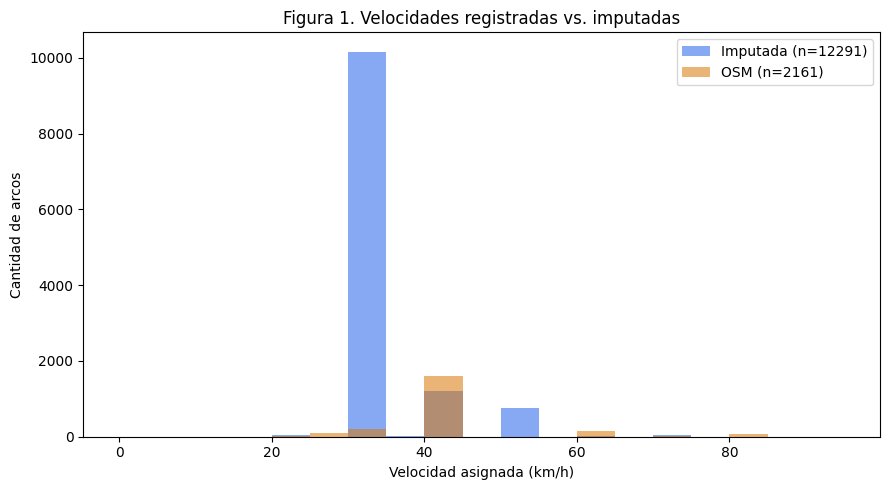

In [6]:
velocidades_por_fuente = {
    fuente: [float(datos["speed_kph"]) for _, _, _, datos in grafo.edges(keys=True, data=True)
             if datos["speed_source"] == fuente]
    for fuente in ["Imputada", "OSM"]
}

fig, ax = plt.subplots(figsize=(9, 5))
for fuente, color in [("Imputada", "#2563eb"), ("OSM", "#d97706")]:
    valores = velocidades_por_fuente[fuente]
    ax.hist(valores, bins=range(0, 100, 5), alpha=0.55, label=f"{fuente} (n={len(valores)})", color=color)
ax.set_xlabel("Velocidad asignada (km/h)")
ax.set_ylabel("Cantidad de arcos")
ax.set_title("Figura 1. Velocidades registradas vs. imputadas")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURAS / "01_velocidades_por_fuente.png", dpi=150, bbox_inches="tight")
plt.show()

**Lectura de la Figura 1:** las velocidades imputadas se concentran exactamente en los
valores discretos de la tabla legal (20, 30, 40, 50, 60, 70, 80 km/h), mientras que las
velocidades registradas en OSM son más dispersas y reflejan condiciones específicas de cada
vía. Esto confirma que el supuesto de imputación introduce una discretización artificial que
no captura variación dentro de una misma clase vial.

## 2. Índice de importancia de las paradas

Para cada parada candidata se combinan dos señales: la densidad poblacional del distrito que
la contiene (INEC, Estimaciones de Población y Vivienda 2022) y la cantidad de destinos
estratégicos (hospitales, clínicas, escuelas, universidades, municipalidades, tribunales y
mercados) dentro de 500 metros (OSM). Ambas variables se normalizan entre 0 y 1 y se combinan:

$$w_i = \alpha \cdot DP_i^{norm} + \beta \cdot DE_i^{norm}, \qquad \alpha=0.6,\ \beta=0.4$$

El índice **no** interviene en el costo de los arcos ni en la función objetivo: solo se usa
para priorizar qué paradas merecen ser puntos de estudio.

In [7]:
paradas = cargar_paradas(DATOS_PROC / "paradas_importantes.csv")
paradas = preparar_paradas(grafo, calcular_importancia(paradas))
paradas_presentacion = usar_nombres_visuales(paradas)
display(paradas_presentacion[[
    "Nombre", "Distrito", "Densidad poblacional",
    "Destinos estratégicos", "Índice de importancia"
]].round(3))
assert len(paradas) >= 20, "Se esperaban al menos 20 paradas"
print("Paradas cargadas:", len(paradas))

,Nombre,Distrito,Densidad poblacional,Destinos estratégicos,Índice de importancia
0,Parada de Autobus.,León XIII,23915.278,3,0.633
1,Terminal León XIII,León XIII,23915.278,0,0.600
2,Torre Mercedes,Hospital,7716.566,31,0.504
3,Ruta Sabana Cementerio,Hospital,7716.566,31,0.504
4,Ruta Cementerio Sabana,Hospital,7716.566,31,0.504
5,Ruta Cementerio Sabana,Hospital,7716.566,31,0.504
6,Hospital de Niños - Paseo Colón,Hospital,7716.566,31,0.504
7,Torre Mercedes,Hospital,7716.566,31,0.504
8,Ruta Sabana Cementerio,Hospital,7716.566,30,0.493
9,Paseo Colon,Hospital,7716.566,30,0.493


Paradas cargadas: 20


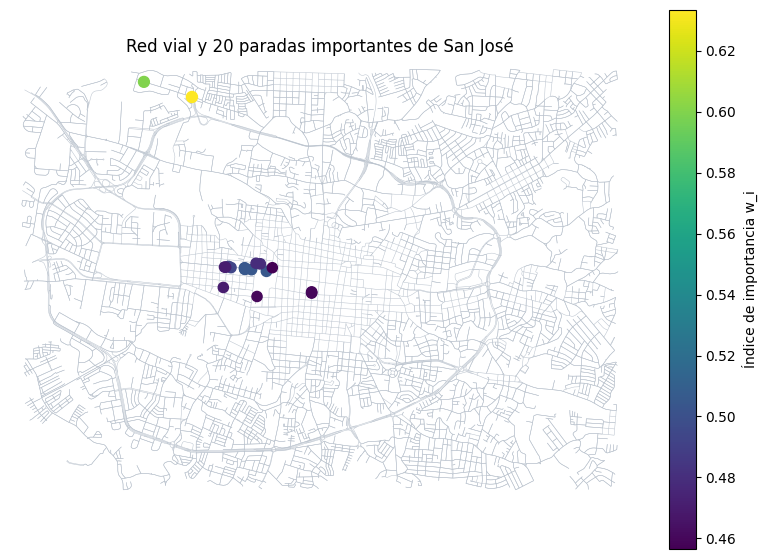

In [8]:
graficar_red_y_paradas(grafo, paradas, FIGURAS / "02_red_paradas_importantes.png")
plt.show()

**Figura 2 (Lectura):** las paradas priorizadas se concentran en sectores centrales y
occidentales de San José. El patrón combina densidad distrital y cercanía a destinos, pero
también muestra menor cobertura espacial en la periferia — una limitación que se documenta
en la Sección 6 del documento final.

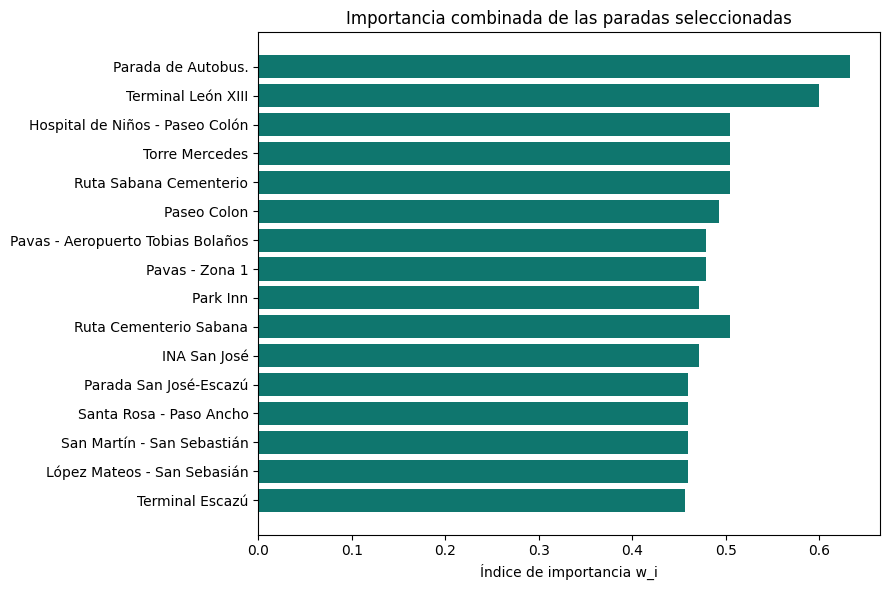

In [9]:
graficar_importancia(paradas, FIGURAS / "03_importancia_paradas.png")
plt.show()

**Figura 3 (Lectura):** las puntuaciones más altas se concentran en León XIII y el casco
central. Los empates entre paradas ocurren cuando comparten distrito y una cantidad similar de
destinos cercanos; el índice es una aproximación mientras no se disponga de demanda observada
de pasajeros.

Estos datos —red vial con costo de viaje y paradas priorizadas— son la base para plantear el
problema de camino mínimo que se resuelve en el notebook `02_modelos.ipynb`.